In [2]:
import torch
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import PCGP.gpytorch_tools as gt
from mpl_toolkits.mplot3d import Axes3D  # Needed for 3D plotting
from matplotlib import cm  # Colormaps
from matplotlib import gridspec
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

In [3]:
plt.rcParams.update({'font.size': 22})
base_dir = os.getcwd()

save_dir = os.path.join(base_dir, "graphs")
output_data_ex1 = os.path.join(base_dir,  "Experiment1_Pedagogical", "output_data")
data_dir_ex2 = os.path.join(base_dir,  "Experiment2_Tripendulum", "output_data")
sim_data_dir_ex2 = os.path.join(base_dir,  "Experiment2_Tripendulum", "input_data")
graph_abstract = os.path.join(base_dir,  "graphs", "graphical_abstract", "output")

#data_dir_ex2 = os.path.join(base_dir, "Experiment2_Bipendulum", "output_data")
#data_dir_ex3 = os.path.join(base_dir, "Experiment3_LumpedHeat", "output_data")

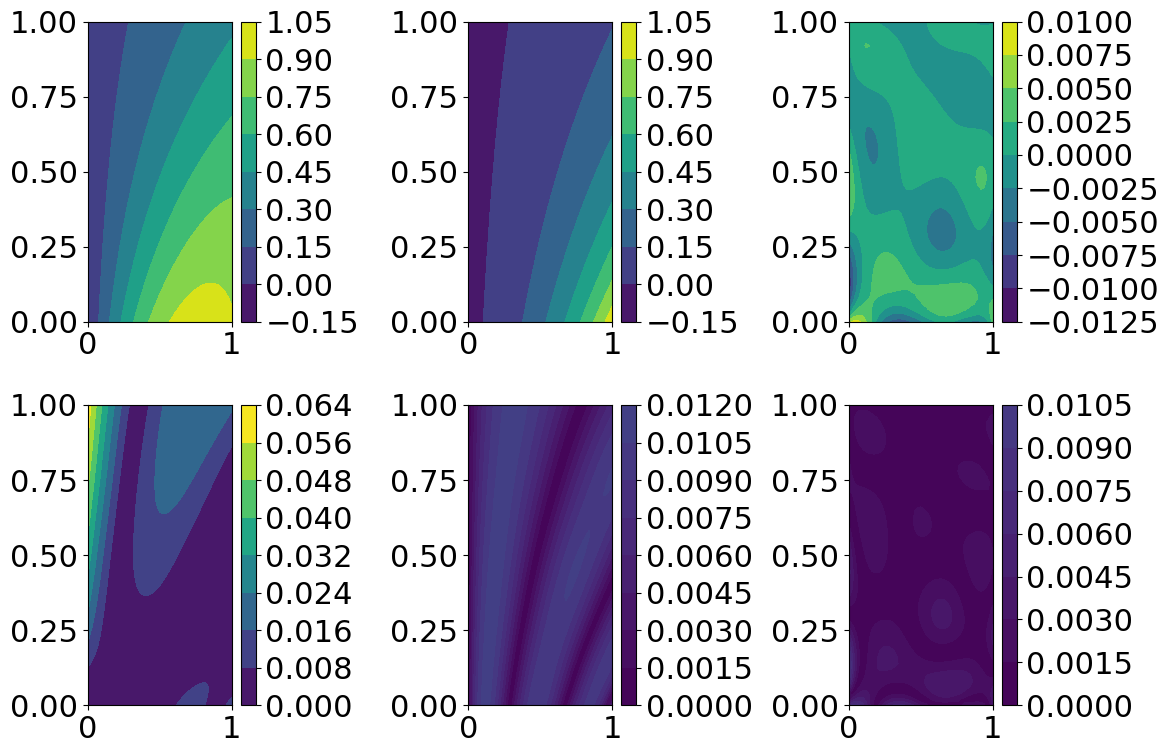

In [8]:
data = np.load(os.path.join(output_data_ex1, f"Ex1_n10_1.npz"))
for key in data:
    globals()[key] = torch.tensor(data[key])
num_tasks = 3
x = test_x[:,0].reshape(51, 51)
t = test_x[:,1].reshape(51, 51)
predicted = mean.reshape(51, 51, num_tasks)
target = test_y.reshape(51, 51, num_tasks)

residual = abs(predicted - target)
res_min = residual.min()
res_max = residual.max()
fig, axs = plt.subplots(2, num_tasks, figsize = (12, 8))
for i in range(num_tasks):
    a = axs[0, i].contourf(x, t, predicted[:,:,i])
    b = axs[1, i].contourf(x, t, residual[:,:,i], vmin = res_min, vmax = res_max)
    fig.colorbar(a, ax=axs[0, i])
    fig.colorbar(b, ax=axs[1, i])
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "Ex1_daweil.png"), dpi=300,bbox_inches='tight')

In [19]:
data_path_ex1 = os.path.join(output_data_ex1, "Ex1_n%i_sigma%.2f_GT.npz"%(10, 0.01))
data_ex1 = np.load(data_path_ex1)
for key in data_ex1:
    print(key)
    if key != "parameter_order":
        globals()[key] = torch.tensor(data_ex1[key])
used_parameters = data_ex1["parameter_order"]
print(test_x.shape)
u = mean[test_x[:,-1] == 0].reshape(51, 51)
v = mean[test_x[:,-1] == 1].reshape(51, 51)
GT = mean[test_x[:,-1] == 2].reshape(51, 51)
error = []
outputs = [u, v, GT]
error = [u-test_y[test_x[:,-1] == 0].reshape(51, 51), v-test_y[test_x[:,-1] == 1].reshape(51, 51), GT]
x = test_x[:,0][test_x[:,-1] == 2].reshape(51, 51)
y = test_x[:,1][test_x[:,-1] == 2].reshape(51, 51)
fig, axes = plt.subplots(2, 3, figsize=(18, 9), constrained_layout=True)

plots = [
    (u, r"$u$", "turbo", 0),
    (v, r"$v$", "turbo", 1),
    (GT, "Ghost task", "turbo", 2),
    (abs(error[0]), "Error u", "turbo", 3),
    (abs(error[1]), "Error v", "turbo", 4),
 (abs(error[2]), "Error GT", "turbo", 5),
]

for ax, (Z, title, cmap, k) in zip(axes.flat, plots):
    surf = ax.contourf(x, y, Z, cmap=cmap, levels=20, alpha=0.9)
    fig.colorbar(surf, ax=ax, shrink=0.7, aspect=15)

    # Training points
    if k<3:
        mask = train_x[:,-1] == k  
        #print(train_x[:,0][mask].shape)
        ax.scatter(train_x[mask, 0], train_x[mask, 1], color="blue", s=8, alpha=0.8)

    # Labels and title
    ax.set_title(title, fontsize=24)
    ax.set_xlabel("x", fontsize=22)
    ax.set_ylabel("y", fontsize=22)
    ax.set_aspect("equal")
    ax.tick_params(axis="both", labelsize=20)
    
plt.savefig(os.path.join(save_dir, "Ex1_inverse.png"), dpi=300, bbox_inches='tight')

plt.figure()
#print(parameters_during_training)
for i in range( len(used_parameters)):
    plt.plot(range(len(parameters_during_training[i,:])), parameters_during_training[i,:], label = used_parameters[i])
plt.legend()
plt.figure()
plt.plot(range(len(loss)), loss)
print(parameters_during_training[1,-1])

FileNotFoundError: [Errno 2] No such file or directory: '/home/johanna/Documents/PhD/project/github/GhostTasking/experiments_ver3/Experiment1_Pedagogical/output_data/Ex1_n10_sigma0.01_GT.npz'

/tmp/ipykernel_31963/1383611524.py:7: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(train_x[mask,0], train_x[mask,1], train_y[mask],  cmap = "jet", label='Train GT',)


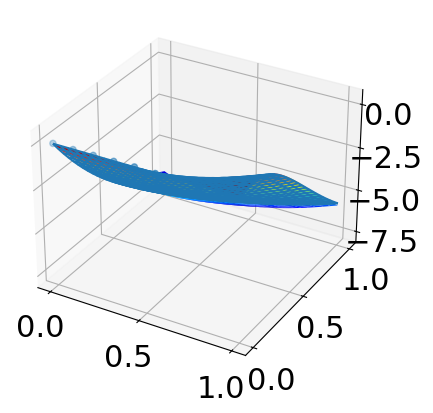

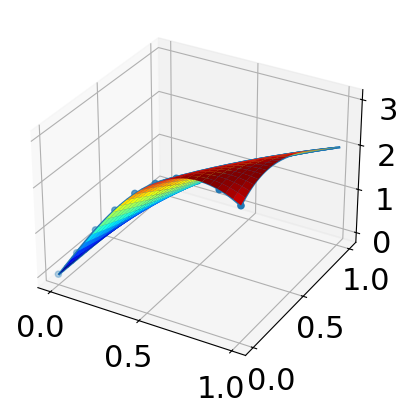

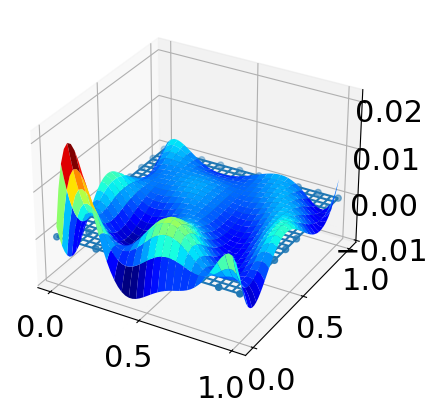

In [18]:
for i in range(3):
    fig, ax = plt.subplots(subplot_kw=dict(projection='3d'))
    mask = test_x[:,-1] == i
    ax.plot_surface(test_x[mask,0].reshape(51, 51), test_x[mask,1].reshape(51, 51), mean[mask].reshape(51, 51),  cmap = "jet", label='Train GT')
    ax.plot_wireframe(test_x[mask,0].reshape(51, 51), test_x[mask,1].reshape(51, 51), test_y[mask].reshape(51, 51),  cmap = "jet", label='Train GT')
    mask = train_x[:,-1] == i
    ax.scatter(train_x[mask,0], train_x[mask,1], train_y[mask],  cmap = "jet", label='Train GT',)




# Experiment 2 Tripendulum

In [24]:
sigma = 0.01
npoint_list = [5] 
modes = ["NSB", "GT", "PIGP"]
num_tasks_list = [5, 6, 4]  # given
run = 0
Al_mode = "fixedAl"
sigma_mode = "extraGTsigma"
point_mode = "extraGTpoints"
data = {}
delta1, delta2, delta3 = [],[],[]
for mode in modes:
    if mode == "GT":
        data_ex2 = np.load(os.path.join(data_dir_ex2, Al_mode, sigma_mode, point_mode,
                                        f"Ex2_{mode}_n{npoints}_sigma{sigma:.2f}_{run}.npz"))
    elif mode == "PIGP":
        data_ex2 = np.load(os.path.join(data_dir_ex2, Al_mode, 
                                        f"Ex2_{mode}_n{npoints}_sigma{sigma:.2f}_{run}.npz"))
    else:
        data_ex2 = np.load(os.path.join(graph_abstract,
                                        f"Ex2_{mode}_n{npoints}_sigma{sigma:.2f}_{run}.npz"))
    for key in data_ex2:
            globals()[key] = torch.tensor(data_ex2[key])
    delta1.append(abs(learned_parameters[0]-true_parameters[0]))
    delta2.append(abs(learned_parameters[1]-true_parameters[1]))
    delta3.append(abs(learned_parameters[0]/learned_parameters[1]-true_parameters[0]/true_parameters[1]))
    print(mode, abs(learned_parameters-true_parameters), abs(learned_parameters[0]/learned_parameters[1]-true_parameters[0]/true_parameters[1]))
    #data[mode]=(abs(learned_parameters[0]-true_parameters[0]), abs(learned_parameters[1]-true_parameters[1]), abs(learned_parameters[0]/learned_parameters[1]-true_parameters[0]/true_parameters[1]))
data[r"""Parameter 1"""] = delta1
data[r"""Parameter 2"""] = delta2
data[r"""Ratio"""] = delta3

metrics = list(data.keys())  # ["Δℓ", "Δg", "Δ(ℓ/g)"]

x = np.arange(len(modes))    # groups = modes
width = 0.1

fig, ax = plt.subplots(figsize=(12, 5))

for i, metric in enumerate(metrics):
    values = data[metric]   # one value per mode
    offset = (i - 1) * width   # center the 3 bars
    rects = ax.bar(x + offset, values, width, label=metric)
    #ax.bar_label(rects, padding=3, fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels([])
ax.set_title("Error metrics", pad = 25)
ax.set_yscale("log")
ax.set_ylabel("MAE")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(ncols = 3, fontsize = 16, loc = (.05, 0.93))
plt.tight_layout(h_pad = 2)
plt.savefig(os.path.join(save_dir, "graphical_abstract_error.png"), dpi=300,bbox_inches='tight')

"""
metrics = data.keys()

x = np.arange(len(metrics))  # the label locations
width = 0.25  # the width of the bars
multiplier = 0
print(data)
fig, ax = plt.subplots(figsize = (9, 5))#layout='constrained')

for attribute, measurement in data.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, measurement, width, label=attribute)
    ax.bar_label(metrics, padding=3)
    multiplier += 1

# Add some text for labels, title and custom x-axis tick labels, etc.
#ax.set_ylabel('Length (mm)')
ax.set_title('Error metrics')
ax.set_xticks(x + width, modes)
#ax.legend(loc='upper left', ncols=3)
#ax.set_ylim(0, 250)
ax.set_yscale("log")
#plt.savefig(os.path.join(save_dir, "graphical_abstract_error.png"), dpi=300,bbox_inches='tight')
"""


FileNotFoundError: [Errno 2] No such file or directory: '/home/johanna/Documents/PhD/project/github/GhostTasking/experiments/graphs/graphical_abstract/output/Ex2_NSB_n25_sigma0.01_0.npz'

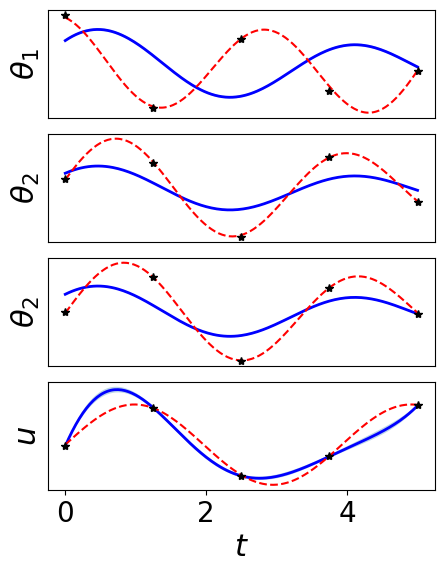

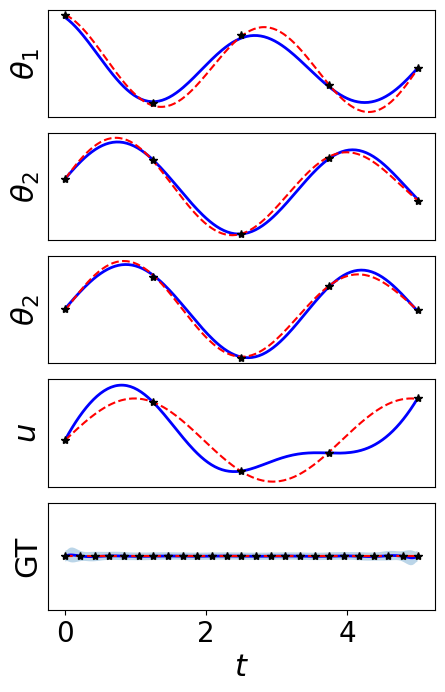

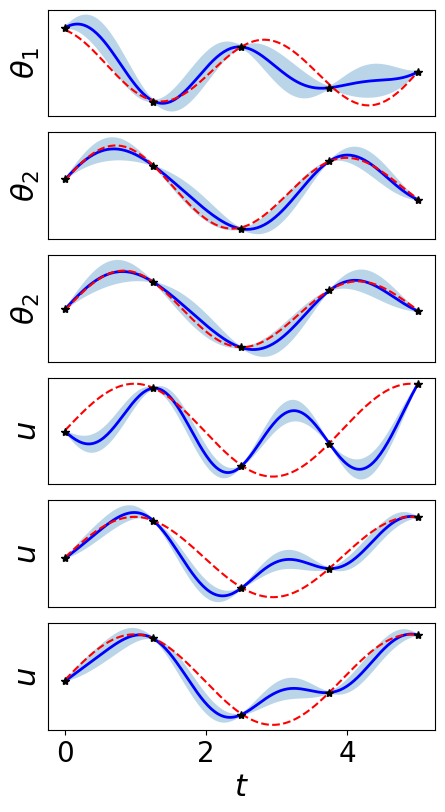

In [210]:
task_labels = [r"$\theta_1$", r"$\theta_2$", r"$\theta_2$", r"$u$", r"$u$", r"$u$"]  
modes = ["NSB", "GT", "PIGP"]
npoints = 5
sigma = 0.1
for mode in modes:
    if mode == "GT":
            data_ex2 = np.load(os.path.join(data_dir_ex2, Al_mode, sigma_mode, point_mode,
                                            f"Ex2_{mode}_n{npoints}_sigma{sigma:.2f}_{run}.npz"))
    elif mode == "PIGP":
        data_ex2 = np.load(os.path.join(data_dir_ex2, Al_mode, 
                                        f"Ex2_{mode}_n{npoints}_sigma{sigma:.2f}_{run}.npz"))
    else:
        data_ex2 = np.load(os.path.join(graph_abstract,
                                        f"Ex2_{mode}_n{npoints}_sigma{sigma:.2f}_{run}.npz"))
    for key in data_ex2:
                    globals()[key] = torch.tensor(data_ex2[key])
    num_tasks = train_y.shape[1]
    #fig, ax = plt.subplots(num_tasks, 1, sharex = True, figsize = (7, .5+train_y.shape[1]))
    height_per_axis = 1.2
    bottom_margin = 0.8     # space for xlabel
    top_margin = 0.3
    hspace = 0.15
    
    fig_height = (
        num_tasks * height_per_axis
        + bottom_margin
        + top_margin
    )
    
    fig, ax = plt.subplots(
        num_tasks,
        1,
        sharex=True,
        figsize=(5, fig_height),
        gridspec_kw={"hspace": hspace}
    )

    for i in range(num_tasks):
                ax[i].plot(test_x, mean[:, i], 'b', linewidth=2)
                ax[i].fill_between(test_x, lower[:, i], upper[:, i], alpha=0.3)
                ax[i].plot(test_x, test_y[:, i], "r--")
                mask = ~torch.isnan(train_y[:, i])
                ax[i].plot(train_x[mask], train_y[mask, i], 'k*')
                if mode == "GT":
                        ax[i].set_ylabel(task_labels[i] if i < 4 else f"GT", fontsize=22)
                        ax[-1].set_ylim([-0.02, +0.02])
                else:
                    ax[i].set_ylabel(task_labels[i] if i < len(task_labels) else f"GT", fontsize=22)
                if i < num_tasks - 1:
                    ax[i].tick_params(labelbottom=False, bottom = False, labelsize=20)
                    ax[i].set_yticks([])
                else:
                    ax[i].set_xlabel(r"$t$", fontsize=22)
                    ax[i].tick_params(labelsize=20)
                    ax[i].set_yticks([])
                    
    fig.subplots_adjust(
    bottom=bottom_margin / fig_height,
    top=1 - top_margin / fig_height
)
    plt.savefig(os.path.join(save_dir, "graphical_abstract_%s.png"%mode), dpi=300,bbox_inches='tight')

IndexError: index 2 is out of bounds for dimension 0 with size 2

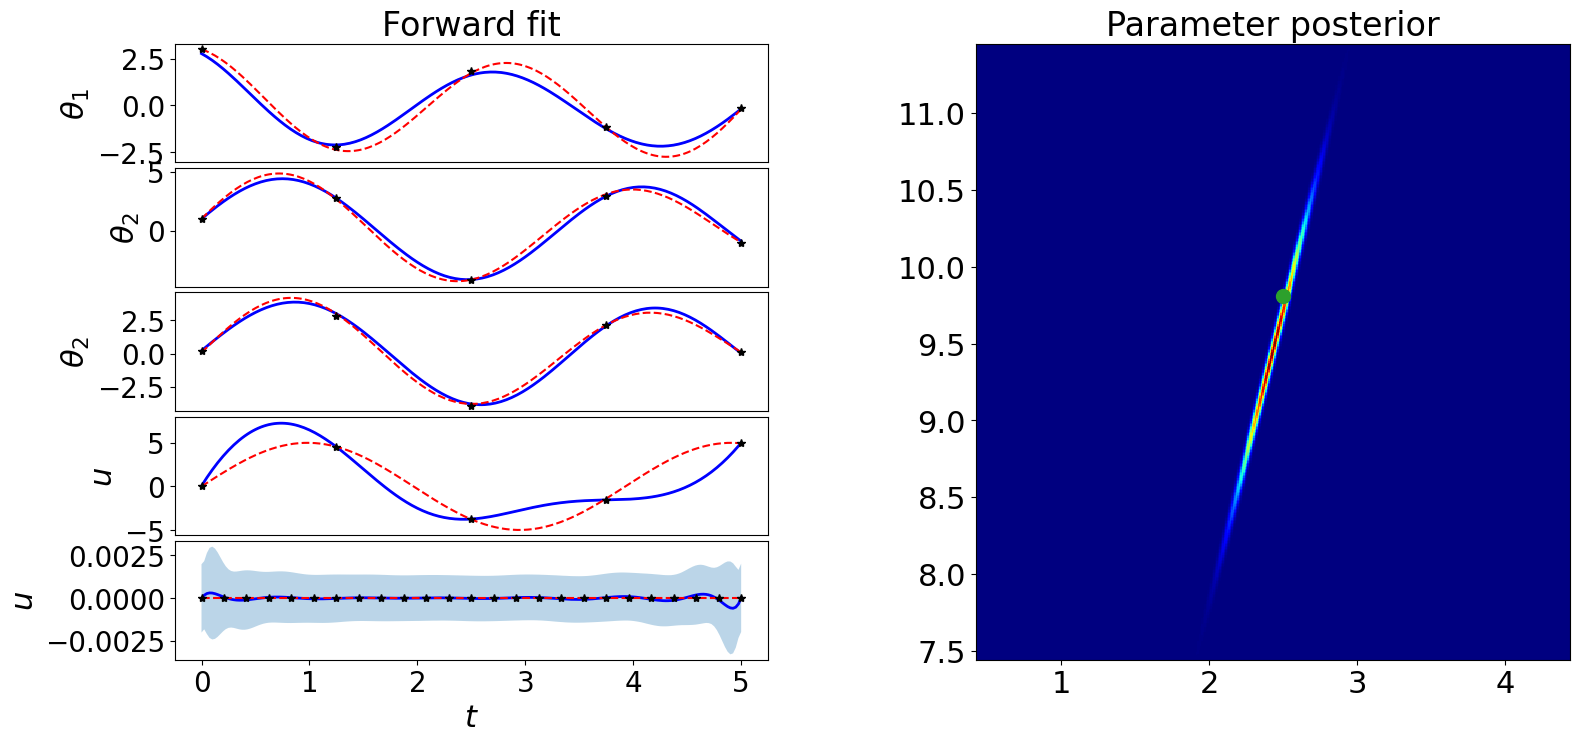

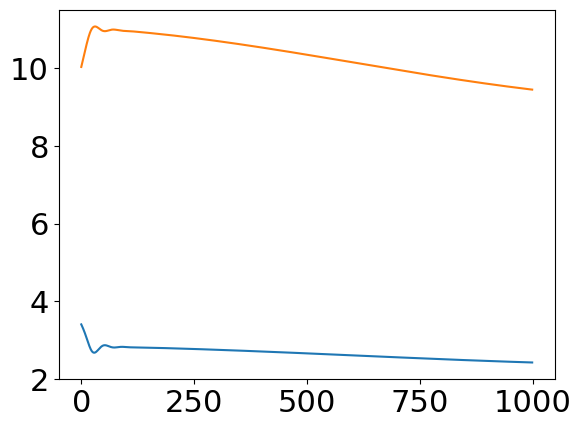

In [86]:
sigma = 0.1
npoints = 5
run = 9

mode = "GT"
title = "GT"
num_tasks = 5

Al_mode = "fixedAl"
sigma_mode = "extraGTsigma"
point_mode = "extraGTpoints"

cmap = "jet"

fig = plt.figure(figsize=(18, 8), constrained_layout=True)
#plt.suptitle(f"{mode}, n={npoints}, σ={sigma}")

task_labels = [r"$\theta_1$", r"$\theta_2$", r"$\theta_2$", r"$u$", r"$u$", r"$u$"]

outer = gridspec.GridSpec(1, 2, width_ratios=[4,4], wspace=0.35)

# ----------------- Load dataset -----------------
data_ex2 = np.load(os.path.join(
    data_dir_ex2, Al_mode, sigma_mode, point_mode,
    f"Ex2_{mode}_n{npoints}_sigma{sigma:.2f}_{run}.npz"
))

for key in data_ex2:
    globals()[key] = torch.tensor(data_ex2[key])

# ----------------- LEFT BLOCK: stacked time series -----------------
inner = gridspec.GridSpecFromSubplotSpec(num_tasks, 1, subplot_spec=outer[0], hspace=0.05)

for i in range(num_tasks):

    ax = fig.add_subplot(inner[i,0])

    ax.plot(test_x, mean[:,i], 'b', linewidth=2)
    ax.fill_between(test_x, lower[:,i], upper[:,i], alpha=0.3)

    ax.plot(test_x, test_y[:,i], "r--")

    mask = ~torch.isnan(train_y[:,i])
    ax.plot(train_x[mask], train_y[mask,i], 'k*')

    ax.set_ylabel(task_labels[i], fontsize=22)

    if i < num_tasks-1:
        ax.tick_params(labelbottom=False, bottom=False, labelsize=20)
    else:
        ax.set_xlabel(r"$t$", fontsize=22)
        ax.tick_params(labelsize=20)

    if i == 0:
        ax.set_title("Forward fit", fontsize=24)

# ----------------- RIGHT BLOCK: parameter posterior -----------------
ax_laplace = fig.add_subplot(outer[1])

N = 400



xlim = (learned_parameters[0]-2, learned_parameters[0]+2)
ylim = (learned_parameters[1]-2, learned_parameters[1]+2)

mesh_1 = torch.linspace(xlim[0], xlim[1], N)
mesh_2 = torch.linspace(ylim[0], ylim[1], N)

param1, param2 = torch.meshgrid(mesh_1, mesh_2, indexing="xy")

mu = learned_parameters[:2]

inv_cov = torch.inverse(laplace_covariance[:2,:2])

param_vec = torch.stack([param1.flatten(), param2.flatten()], dim=-1)

exponent_raw = torch.einsum(
        'bi,ij,bj->b',
        param_vec - mu,
        inv_cov,
        param_vec - mu
    )

prob_density = torch.exp(-0.5*(exponent_raw - exponent_raw.min()))
prob_density /= prob_density.sum()*(mesh_1[1]-mesh_1[0])*(mesh_2[1]-mesh_2[0])

prob_density = prob_density.reshape(N,N)

surf = ax_laplace.pcolormesh(
        param1, param2, prob_density,
        cmap=cmap,
        shading="auto"
    )

ax_laplace.plot(true_parameters[0], true_parameters[1], color = "C2", marker = "o",  markersize = 10)
    #ax_laplace.plot(learned_parameters[0], learned_parameters[1], "rx")

ax_laplace.set_title("Parameter posterior", fontsize=24)


#plt.savefig(os.path.join(save_dir, "Ex2_PoC.png"), dpi=300,bbox_inches='tight' )

plt.figure()
#print(parameters_during_training)
for i in range( len(used_parameters)):
    plt.plot(range(len(parameters_during_training[i,:])), parameters_during_training[i,:], label = used_parameters[i])
plt.legend()

<>:97: SyntaxWarning: invalid escape sequence '\e'
<>:97: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_6248/1617679965.py:97: SyntaxWarning: invalid escape sequence '\e'
  """ax_laplace.set_xlabel(r"$\ell_1$", fontsize=22)
/home/johanna/VENTUS/lib/python3.13/site-packages/IPython/core/events.py:82: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  func(*args, **kwargs)
/home/johanna/VENTUS/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.canvas.print_figure(bytes_io, **kw)


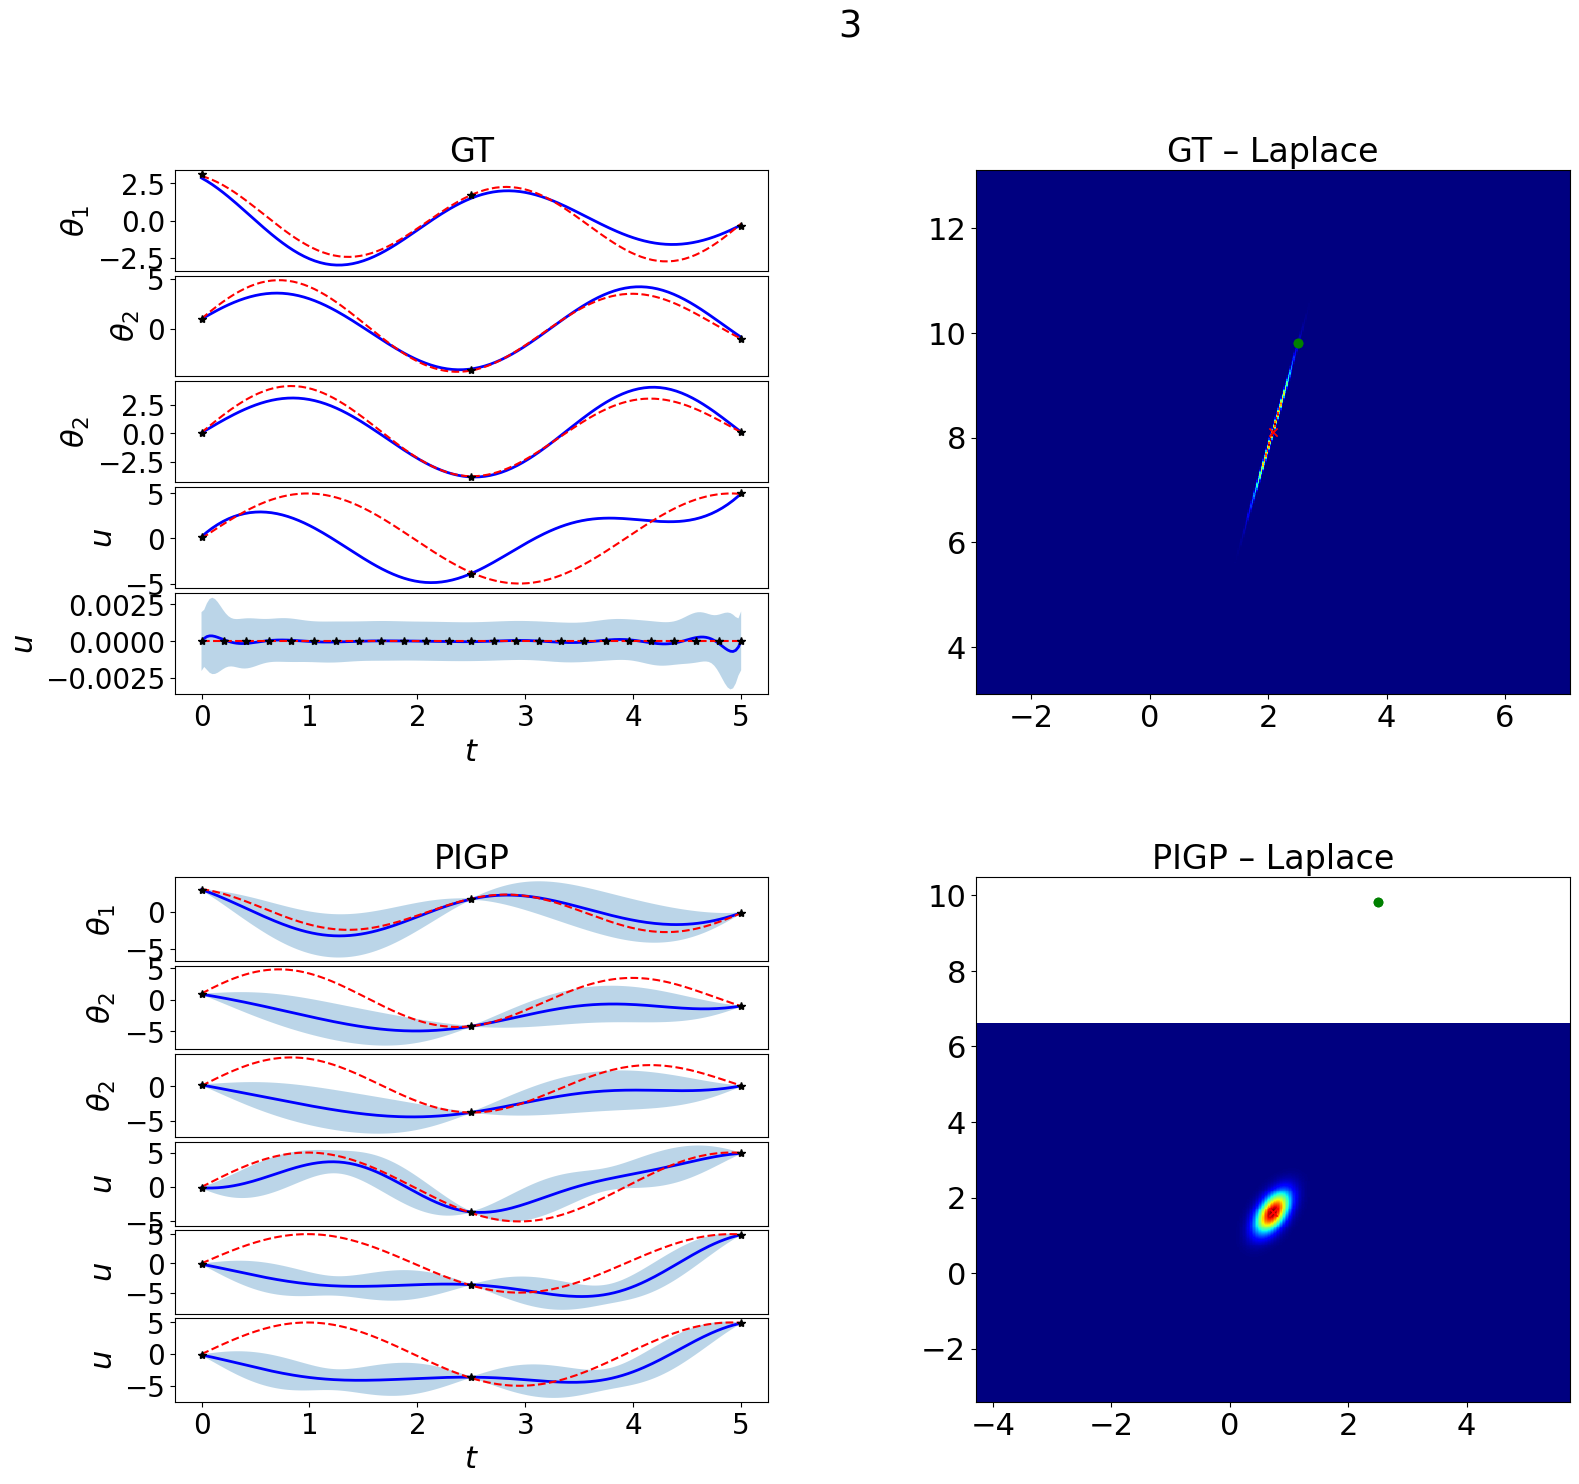

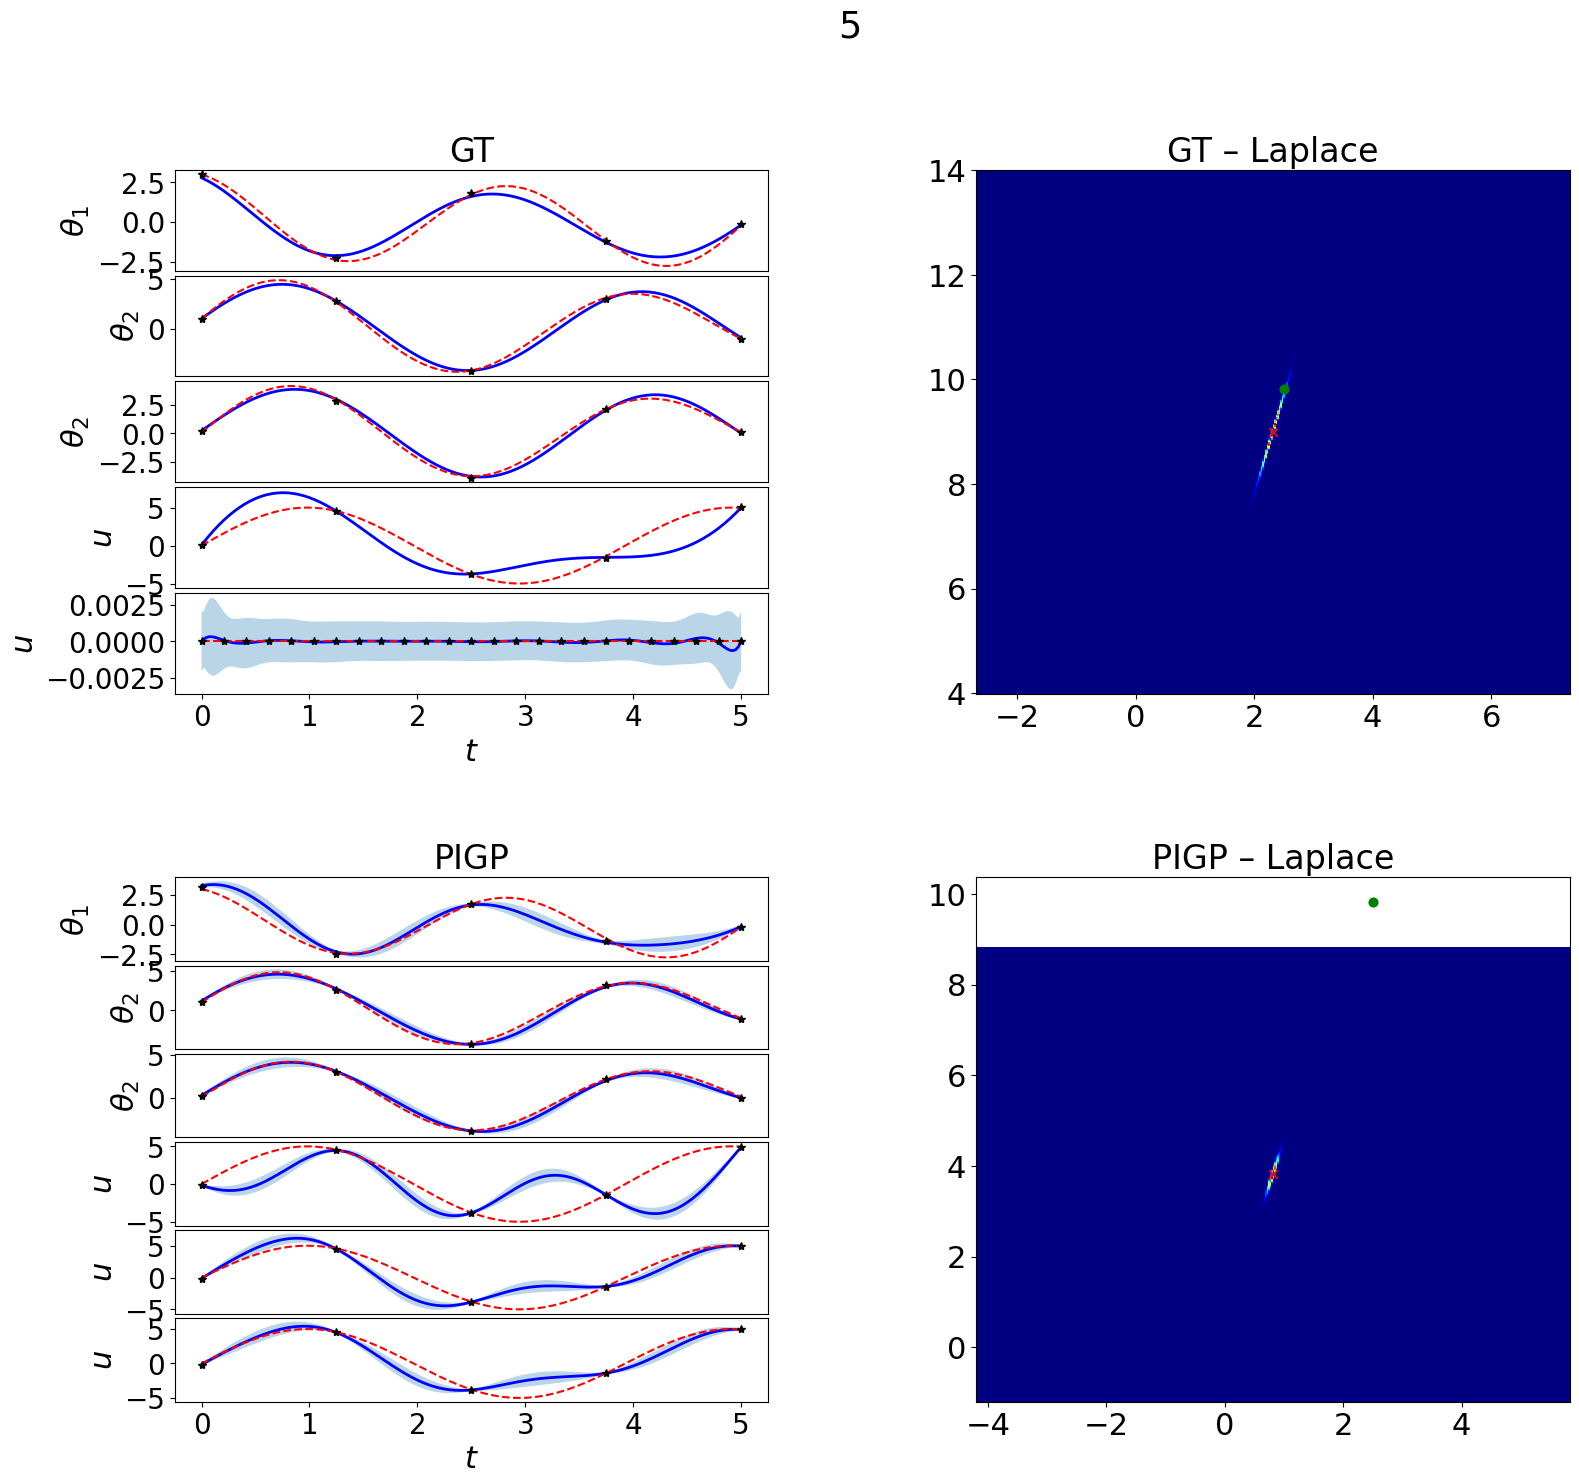

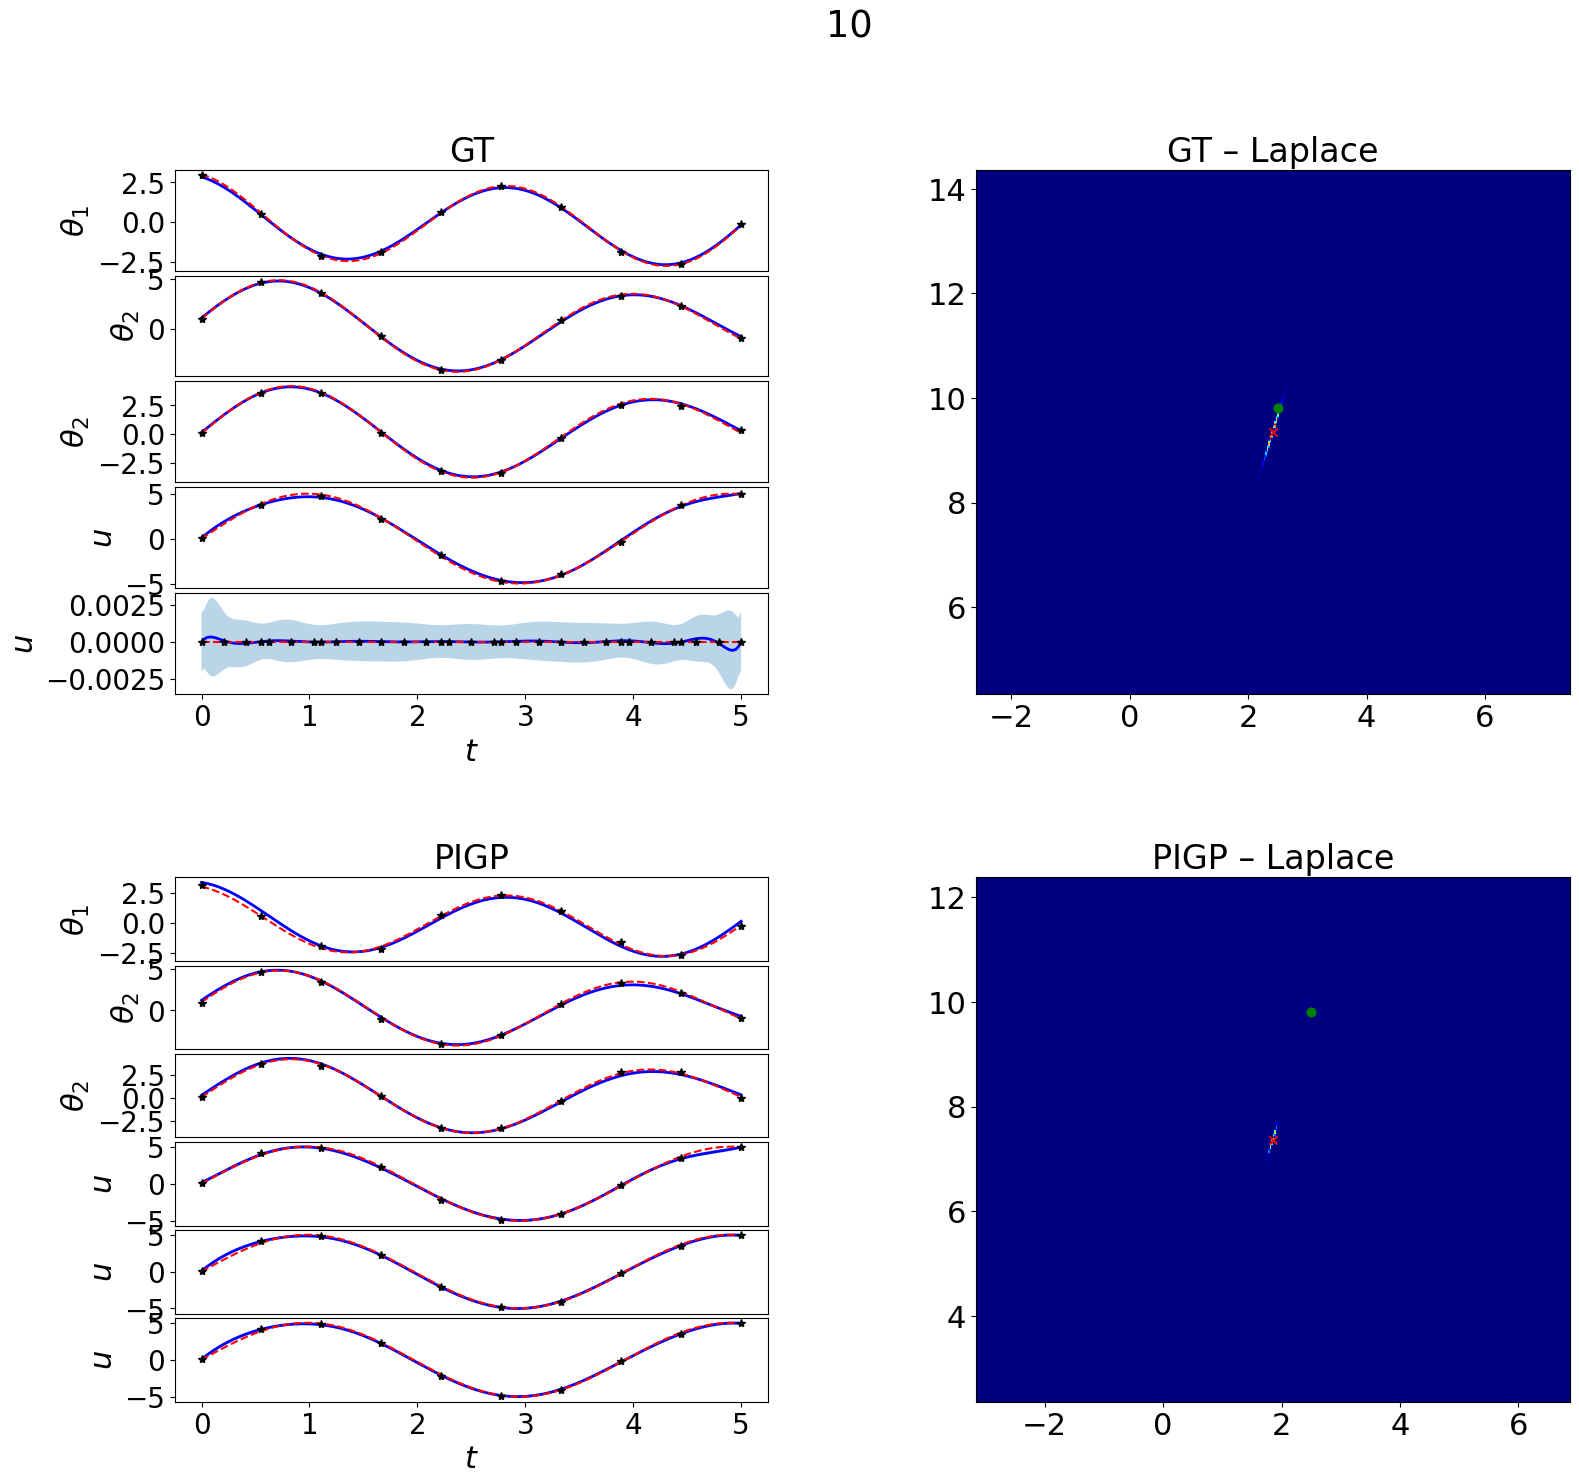

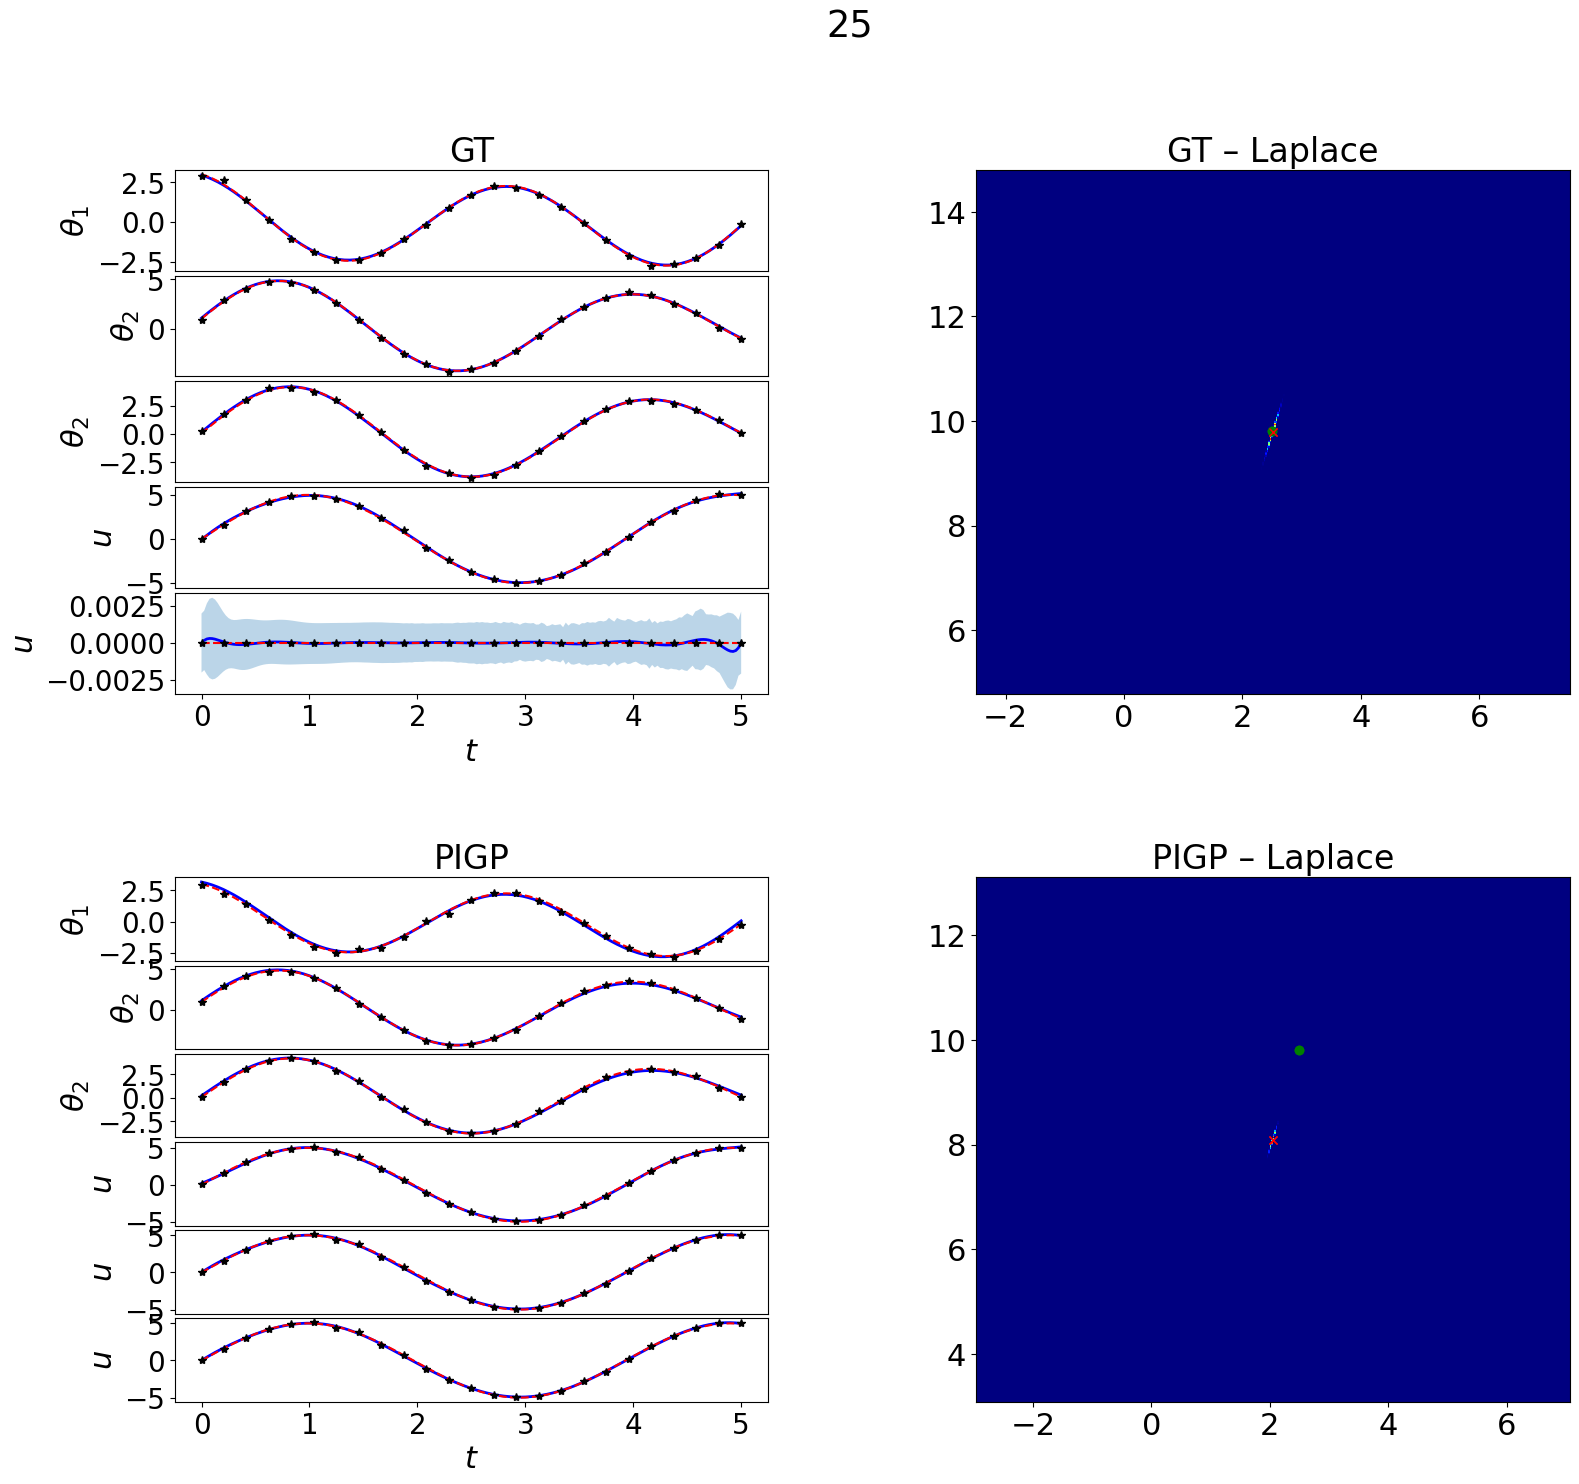

In [102]:
#npoints = 10
sigma = 0.1
npoint_list = [3, 5, 10, 25] 
modes = ["GT", "PIGP"]
titles = ["GT", "PIGP"]
num_tasks_list = [5, 6]  # given
run = 3
Al_mode = "fixedAl"
sigma_mode = "extraGTsigma"
point_mode = "extraGTpoints"
for npoints in npoint_list:
        
    
    
    cmap = "jet"
    fig = plt.figure(figsize=(18, 16), constrained_layout=True)
    plt.suptitle(npoints)
    task_labels = [r"$\theta_1$", r"$\theta_2$", r"$\theta_2$", r"$u$", r"$u$", r"$u$"]  
    color_axes = []
    # Outer GridSpec: 3 rows × 1 column, height proportional to num_tasks
    outer = gridspec.GridSpec(2, 1,  hspace=0.35)
    
    for row, (mode, title,  num_tasks) in enumerate(zip(modes, titles, num_tasks_list)):
    
        # ----------------- Load dataset -----------------
      
        if mode == "GT":
            data_ex2 = np.load(os.path.join(data_dir_ex2, Al_mode, sigma_mode, point_mode,
                                            f"Ex2_{mode}_n{npoints}_sigma{sigma:.2f}_{run}.npz"))
        else:
            data_ex2 = np.load(os.path.join(data_dir_ex2, Al_mode, 
                                            f"Ex2_{mode}_n{npoints}_sigma{sigma:.2f}_{run}.npz"))
        for key in data_ex2:
                globals()[key] = torch.tensor(data_ex2[key])
    
        # ----------------- Create nested GridSpec per row -----------------
        row_gs = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=outer[row], width_ratios=[4, 4], wspace=0.35)
            
    
    
        # ----------------- LEFT BLOCK: stacked time series -----------------
        inner = gridspec.GridSpecFromSubplotSpec(num_tasks, 1, subplot_spec=row_gs[0], hspace=0.05)
        for i in range(num_tasks):
            ax = fig.add_subplot(inner[i, 0])
            ax.plot(test_x, mean[:, i], 'b', linewidth=2)
            ax.fill_between(test_x, lower[:, i], upper[:, i], alpha=0.3)
            ax.plot(test_x, test_y[:, i], "r--")
            mask = ~torch.isnan(train_y[:, i])
            ax.plot(train_x[mask], train_y[mask, i], 'k*')
            ax.set_ylabel(task_labels[i] if i < len(task_labels) else f"f_{i+1}", fontsize=22)
            if i < num_tasks - 1:
                ax.tick_params(labelbottom=False, bottom = False, labelsize=20)
            else:
                ax.set_xlabel(r"$t$", fontsize=22)
                ax.tick_params(labelsize=20)
            if i == 0:
                ax.set_title(title, fontsize=24)
           # ax.tick_params(labelsize=16)  # smaller font for stacked plots
            """ax.set_ylabel(task_labels[i], fontsize=18)
            if i==1:
                y_ticks = [8, 0, -8]
            if i>=2:
                y_ticks = [10, 0, -10]
            if i == 0: 
                y_ticks = [4, 0, -4]
            ax.set_yticks(y_ticks)
            ax.set_yticklabels([f"{t:.0f}" for t in y_ticks], fontsize=16)"""
        # ----------------- MIDDLE BLOCK: Laplace / Bayes posterior -----------------
        ax_laplace = fig.add_subplot(row_gs[1])
        if mode != "Bayes":
            # Laplace plotting code
            N = 400
            ax_laplace.plot(true_parameters[0], true_parameters[1], "go")
            ax_laplace.plot(learned_parameters[0], learned_parameters[1], "rx")
            xlim = (learned_parameters[0]-5, learned_parameters[0]+5)
            ylim = (learned_parameters[1]-5, learned_parameters[1]+5)
            mesh_1 = torch.linspace(xlim[0], xlim[1], N)
            mesh_2 = torch.linspace(ylim[0], ylim[1], N)
            param1, param2 = torch.meshgrid(mesh_1, mesh_2, indexing="xy")
            mu = learned_parameters[:2]
            try:
                inv_cov = torch.inverse(laplace_covariance[:2, :2])
                param_vec = torch.stack([param1.flatten(), param2.flatten()], dim=-1)
                exponent_raw = torch.einsum('bi,ij,bj->b', param_vec - mu, inv_cov, param_vec - mu)
                prob_density = torch.exp(-0.5 * (exponent_raw - exponent_raw.min()))
                prob_density /= prob_density.sum() * (mesh_1[1]-mesh_1[0])*(mesh_2[1]-mesh_2[0])
                prob_density = prob_density.reshape(N, N)
        
                surf = ax_laplace.pcolormesh(param1, param2, prob_density, cmap=cmap, shading="auto")
                ax_laplace.plot(true_parameters[0], true_parameters[1], "go")
                ax_laplace.plot(learned_parameters[0], learned_parameters[1], "rx")
                ax_laplace.set_title(f"{title} – Laplace", fontsize=24)
            except:
               print(npoints, sigma, "there was a problem with the covariance")
       
    
        """ax_laplace.set_xlabel(r"$\ell_1$", fontsize=22)
        x_ticks = [0.85, 1.0, 1.15]
        ax_laplace.set_xticks(x_ticks)
        ax_laplace.set_xticklabels([f"{t:.2f}" for t in x_ticks], fontsize=22)
        ax_laplace.set_ylabel(r"$\ell_2$", fontsize=22)"""
    
        
    
    
    #plt.savefig(os.path.join(save_dir, "Ex2.png"), dpi=300,bbox_inches='tight')

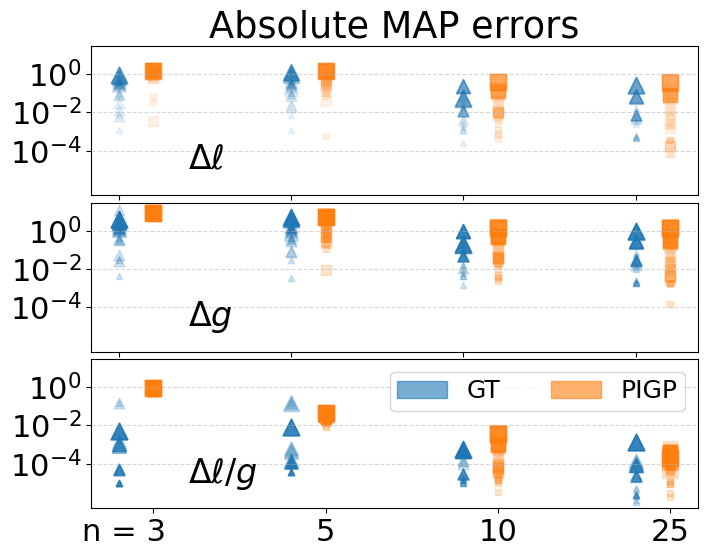

In [143]:
runs = 10

sigma_list = [0.0, 0.01, 0.1, 0.2]
n_list = [3, 5, 10, 25]
modes = ["GT", "PIGP"]
all_AE = np.zeros((len(n_list), len(sigma_list), len(modes), 3, runs))

Al = ["withAl", "fixedAl"] #fixedAl #hier PIGP
GTsigma = ["no_extraGTsigma", "extraGTsigma"]
GTpoints = ["extraGTpoints", "extraGTpoints"] #hier GT

Al_mode = "withAl"
sigma_mode = "extraGTsigma"
point_mode = "extraGTpoints"
for n_idx, npoints in enumerate(n_list):
    for sigma_idx, sigma in enumerate(sigma_list):
        for j, mode in enumerate(modes):
            for run in range(0, runs):
                if mode == "GT":
                    data_ex2 = np.load(os.path.join(data_dir_ex2, Al_mode, sigma_mode, point_mode,
                                                    f"Ex2_{mode}_n{npoints}_sigma{sigma:.2f}_{run}.npz"))
                    learned_parameters = data_ex2["learned_parameters"]
                    true_parameters = data_ex2["true_parameters"]
                else:
                    data_ex2 = np.load(os.path.join(data_dir_ex2, Al_mode, 
                                                    f"Ex2_{mode}_n{npoints}_sigma{sigma:.2f}_{run}.npz"))
                    learned_parameters = data_ex2["learned_parameters"]
                    true_parameters = data_ex2["true_parameters"]
                all_AE[n_idx, sigma_idx, j, 0, run] = abs(learned_parameters[0]-true_parameters[0]) 
                all_AE[n_idx, sigma_idx, j, 1, run] = abs(learned_parameters[1]-true_parameters[1])
                all_AE[n_idx, sigma_idx, j, 2, run] = abs(learned_parameters[0]/learned_parameters[1]-true_parameters[0]/true_parameters[1])
#for plotting
width = 0.05
group_spacing = 0.3
num_boxes_per_group = 4
scale_factor = 40
base_size = 20
symbol = ["^", "s",]
markers = ["x", "+", 1/np.sqrt(2), 1]
colors = list(mcolors.TABLEAU_COLORS.values())

fig = plt.figure(figsize=(18, 6))
gs = gridspec.GridSpec(1, 2, width_ratios=[2, 2], wspace=0.3)

# --- LEFT AXIS: split into 2 rows ---
gs_left = gridspec.GridSpecFromSubplotSpec(3, 1, subplot_spec=gs[0, 0], hspace=0.05)
ax00 = fig.add_subplot(gs_left[0, 0])  # top subplot
ax01 = fig.add_subplot(gs_left[1, 0], sharey=ax00)  # bottom subplot
ax02 = fig.add_subplot(gs_left[2, 0], sharey=ax00)  # bottom subplot



#j_list = [0, 1, 2, 3]

# --- LEFT TOP: parameter = l
for n_idx, n in enumerate(n_list):
    group_pos = n_idx * (num_boxes_per_group * width + group_spacing)
    for mode in range(2):  # j=0,1
        pos = group_pos + 2 * mode * width
        for sigma_idx, sigma in enumerate(sigma_list):
            data = all_AE[n_idx, sigma_idx, mode, 0]
            x_vals = np.full(len(data), pos)
            marker_size = base_size + scale_factor * sigma_idx
            ax00.scatter(x_vals, data,
                         marker=symbol[mode], color=colors[mode % len(colors)],
                         alpha=0.1, s=marker_size,
                         label=f'σ={sigma:.2f}' if n_idx == 0 and j == 0 else None)
            """if n in [2,3,4,5, 7]:
                extra_y = np.atleast_1d(all_AE_end2[n_idx, sigma_idx, j])
                ax00.scatter(np.full(len(extra_y), pos), extra_y,
                            marker=markers[j], color="black", alpha=0.1,#colors[j % len(colors)]
                            s=marker_size*markers[j+2])
                ax00.tick_params(labelbottom=False, bottom = False, labelsize=20)"""
ax00.text(0.2, 1e-5, r"""$\Delta \ell$""", fontsize=24)
# --- LEFT BOTTOM: parameter = g
for n_idx, n in enumerate(n_list):
    group_pos = n_idx * (num_boxes_per_group * width + group_spacing)
    for mode in range(2): 
        pos = group_pos + 2 * (mode) * width  # reset spacing for bottom row
        for sigma_idx, sigma in enumerate(sigma_list):
            data = all_AE[n_idx, sigma_idx, mode, 1]
            x_vals = np.full(len(data), pos)
            marker_size = base_size + scale_factor * sigma_idx
            ax01.scatter(x_vals, data,
                         marker=symbol[mode], color=colors[(mode) % len(colors)],
                         alpha=0.2, s=marker_size,
                         label=f'σ={sigma:.2f}' if n_idx == 0 and j == 2 else None)
            """if n in [2,3,4,5, 7]:
                extra_y = np.atleast_1d(all_AE_end2[n_idx, sigma_idx, j])
                ax01.scatter(np.full(len(extra_y), pos), extra_y,
                            marker=markers[j-2], color = "black" , alpha=0.1,#color=colors[(j-2) % len(colors)]
                            s=marker_size*markers[j])"""
ax01.text(0.2, 1e-5, r"""$\Delta g$""", fontsize=24)

for n_idx, n in enumerate(n_list):
    group_pos = n_idx * (num_boxes_per_group * width + group_spacing)
    for mode in range(2): 
        pos = group_pos + 2 * (mode) * width  # reset spacing for bottom row
        for sigma_idx, sigma in enumerate(sigma_list):
            data = all_AE[n_idx, sigma_idx, mode, 2]
            x_vals = np.full(len(data), pos)
            marker_size = base_size + scale_factor * sigma_idx
            ax02.scatter(x_vals, data,
                         marker=symbol[mode], color=colors[(mode) % len(colors)],
                         alpha=0.2, s=marker_size,
                         label=f'σ={sigma:.2f}' if n_idx == 0 and j == 2 else None)
            """if n in [2,3,4,5, 7]:
                extra_y = np.atleast_1d(all_AE_end2[n_idx, sigma_idx, j])
                ax01.scatter(np.full(len(extra_y), pos), extra_y,
                            marker=markers[j-2], color = "black" , alpha=0.1,#color=colors[(j-2) % len(colors)]
                            s=marker_size*markers[j])"""
ax02.text(0.2, 1e-5, r"""$\Delta \ell/g$""", fontsize=24)
# --- format LEFT subplots ---
for ax in [ax00, ax01, ax02]:
    AE_xtick_positions = [i * (num_boxes_per_group * width + group_spacing)
                          + width*num_boxes_per_group/2 for i in range(len(n_list))]
    AE_xtick_labels = ["n = 3      " if n == 3 else f"{n}" for n in n_list]
    ax02.set_xticks(AE_xtick_positions, AE_xtick_labels)
    ax.set_yscale("log")
    ax.set_yticks([10**(2*i) for i in [-2, -1, 0]])
    ax.grid(True, axis='y', linestyle='--', alpha=0.5)
ax00.set_title("Absolute MAP errors")
#ax01.set_title("Absolute MAP errors (j=2,3)")
#ax01.set_ylabel("Absolute Error")
import matplotlib.patches as mpatches

gt_patch = mpatches.Patch(color=colors[0], label="GT", alpha=0.6)
pigp_patch = mpatches.Patch(color=colors[1], label="PIGP", alpha=0.6)

ax02.legend(handles=[gt_patch, pigp_patch], ncols = 2, fontsize = 18, borderpad = 0.3)

plt.savefig(os.path.join(save_dir, "Ex2_metrics.png"), dpi=300,bbox_inches='tight' )

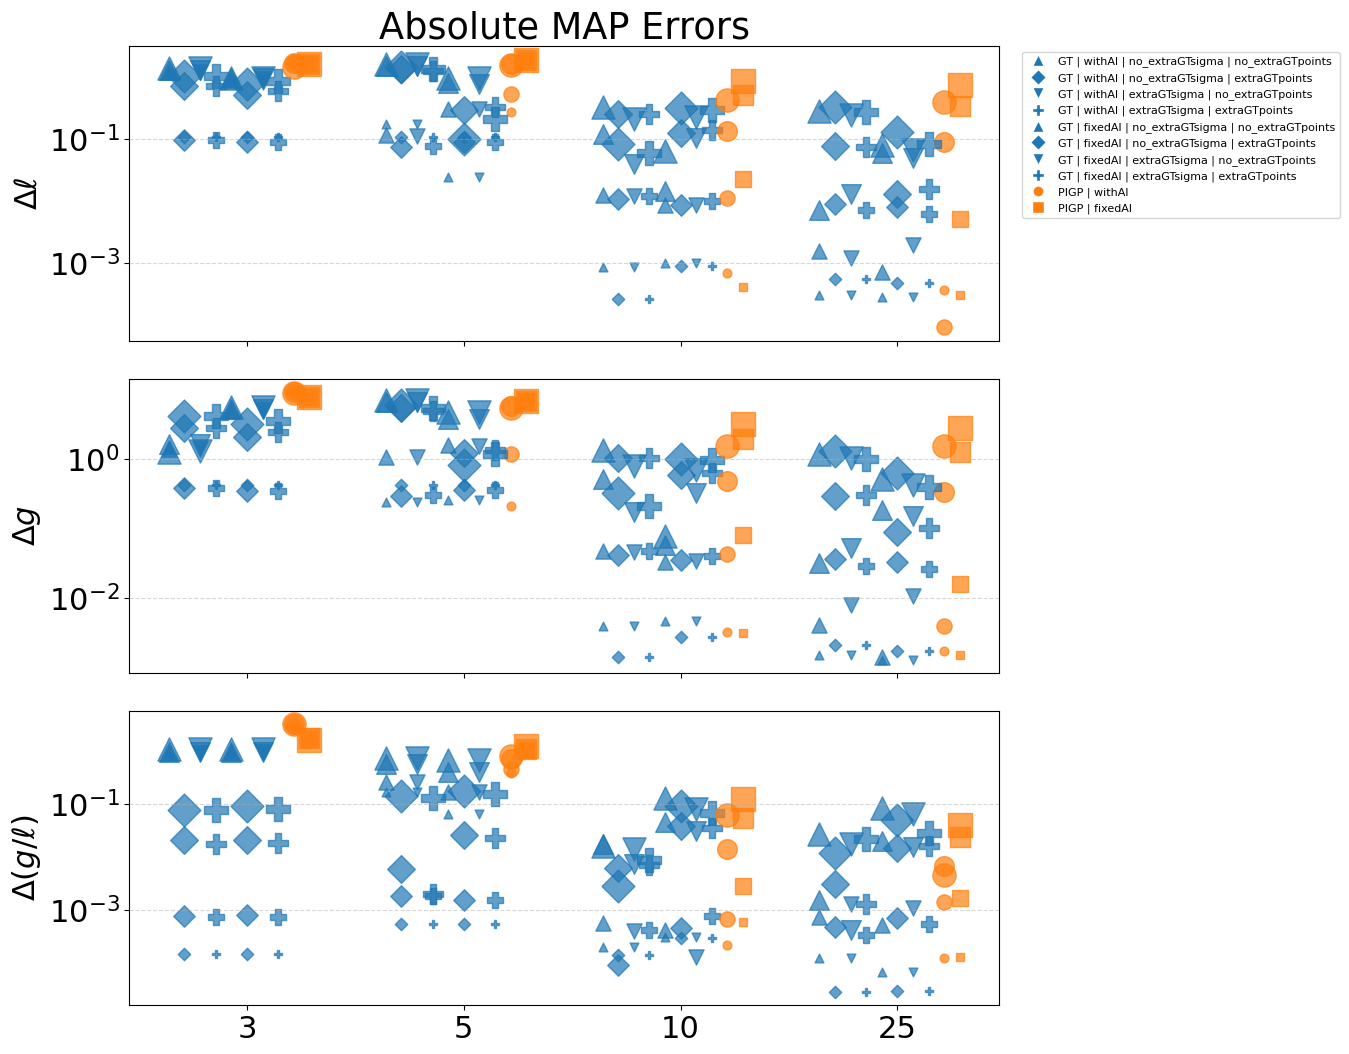

In [36]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# --------------------------------------------------
# Configuration
# --------------------------------------------------
run = 0

sigma_list = [0.0, 0.01, 0.1, 0.2]
n_list = [3, 5, 10, 25]
modes = ["GT", "PIGP"]

Al_options = ["withAl", "fixedAl"]
GTsigma_options = ["no_extraGTsigma", "extraGTsigma"]
GTpoints_options = ["no_extraGTpoints", "extraGTpoints"]

colors = {"GT": "tab:blue", "PIGP": "tab:orange"}

markers_PIGP = {
    "withAl": "o",
    "fixedAl": "s"
}

markers_GT = {
    ("no_extraGTsigma", "no_extraGTpoints"): "^",
    ("extraGTsigma", "no_extraGTpoints"): "v",
    ("no_extraGTsigma", "extraGTpoints"): "D",
    ("extraGTsigma", "extraGTpoints"): "P"
}

# --------------------------------------------------
# Collect errors
# --------------------------------------------------
all_AE = []

for n in n_list:
    for sigma in sigma_list:
        for mode in modes:

            if mode == "GT":
                for Al_mode in Al_options:
                    for GTsigma_mode in GTsigma_options:
                        for GTpoints_mode in GTpoints_options:

                            path = os.path.join(
                                data_dir_ex2,
                                Al_mode,
                                GTsigma_mode,
                                GTpoints_mode,
                                f"Ex2_{mode}_n{n}_sigma{sigma:.2f}_{run}.npz"
                            )


                            data = np.load(path)
                            lp = data["learned_parameters"]
                            tp = data["true_parameters"]

                            l_hat, g_hat = lp[0], lp[1]
                            l_true, g_true = tp[0], tp[1]

                            ratio_hat = g_hat / l_hat
                            ratio_true = g_true / l_true

                            all_AE.append({
                                "n": n,
                                "sigma": sigma,
                                "mode": mode,
                                "Al": Al_mode,
                                "GTsigma": GTsigma_mode,
                                "GTpoints": GTpoints_mode,
                                "d_l": abs(l_hat - l_true),
                                "d_g": abs(g_hat - g_true),
                                "d_ratio": abs(ratio_hat - ratio_true)
                            })

            else:  # PIGP
                for Al_mode in Al_options:

                    path = os.path.join(
                        data_dir_ex2,
                        Al_mode,
                        f"Ex2_{mode}_n{n}_sigma{sigma:.2f}_{run}.npz"
                    )

                    

                    data = np.load(path)
                    lp = data["learned_parameters"]
                    tp = data["true_parameters"]

                    l_hat, g_hat = lp[0], lp[1]
                    l_true, g_true = tp[0], tp[1]

                    ratio_hat = g_hat / l_hat
                    ratio_true = g_true / l_true

                    all_AE.append({
                        "n": n,
                        "sigma": sigma,
                        "mode": mode,
                        "Al": Al_mode,
                        "GTsigma": None,
                        "GTpoints": None,
                        "d_l": abs(l_hat - l_true),
                        "d_g": abs(g_hat - g_true),
                        "d_ratio": abs(ratio_hat - ratio_true)
                    })

# --------------------------------------------------
# Build configuration index
# --------------------------------------------------
config_list = []

for mode in modes:
    if mode == "GT":
        for Al_mode in Al_options:
            for GTsigma_mode in GTsigma_options:
                for GTpoints_mode in GTpoints_options:
                    config_list.append((mode, Al_mode, GTsigma_mode, GTpoints_mode))
    else:
        for Al_mode in Al_options:
            config_list.append((mode, Al_mode, None, None))

config_index = {cfg: i for i, cfg in enumerate(config_list)}
n_configs = len(config_list)

# --------------------------------------------------
# Plot (3 rows now)
# --------------------------------------------------
fig, (ax_l, ax_g, ax_ratio) = plt.subplots(
    3, 1, figsize=(14, 11), sharex=True
)

group_spacing = 2.5
config_spacing = 0.18
base_size = 40
scale_factor = 80

for entry in all_AE:

    n_idx = n_list.index(entry["n"])
    group_center = n_idx * group_spacing

    cfg = (entry["mode"], entry["Al"], entry["GTsigma"], entry["GTpoints"])
    offset_id = config_index[cfg]

    x_pos = group_center + (offset_id - n_configs/2) * config_spacing

    color = colors[entry["mode"]]

    if entry["mode"] == "GT":
        marker = markers_GT[(entry["GTsigma"], entry["GTpoints"])]
    else:
        marker = markers_PIGP[entry["Al"]]

    size = base_size + scale_factor * sigma_list.index(entry["sigma"])

    ax_l.scatter(x_pos, entry["d_l"],
                 marker=marker, color=color,
                 s=size, alpha=0.7)

    ax_g.scatter(x_pos, entry["d_g"],
                 marker=marker, color=color,
                 s=size, alpha=0.7)

    ax_ratio.scatter(x_pos, entry["d_ratio"],
                     marker=marker, color=color,
                     s=size, alpha=0.7)

# --------------------------------------------------
# Formatting
# --------------------------------------------------
for ax, label in zip(
        [ax_l, ax_g, ax_ratio],
        [r"$\Delta \ell$",
         r"$\Delta g$",
         r"$\Delta (g/\ell)$"]):

    ax.set_yscale("log")
    ax.set_ylabel(label)
    ax.grid(True, axis="y", linestyle="--", alpha=0.5)

ax_ratio.set_xticks(
    [i * group_spacing for i in range(len(n_list))],
    n_list
)

ax_l.set_title("Absolute MAP Errors")

# --------------------------------------------------
# Legend
# --------------------------------------------------
legend_elements = []

for cfg in config_list:
    mode, Al_mode, GTsigma_mode, GTpoints_mode = cfg
    color = colors[mode]

    if mode == "GT":
        marker = markers_GT[(GTsigma_mode, GTpoints_mode)]
        label = f"GT | {Al_mode} | {GTsigma_mode} | {GTpoints_mode}"
    else:
        marker = markers_PIGP[Al_mode]
        label = f"PIGP | {Al_mode}"

    legend_elements.append(
        Line2D([0], [0], marker=marker, color='w',
               markerfacecolor=color,
               label=label, markersize=8)
    )

ax_l.legend(handles=legend_elements,
            bbox_to_anchor=(1.02, 1),
            loc="upper left",
            fontsize=8)

plt.tight_layout()
plt.show()

/tmp/ipykernel_6248/2769138600.py:104: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


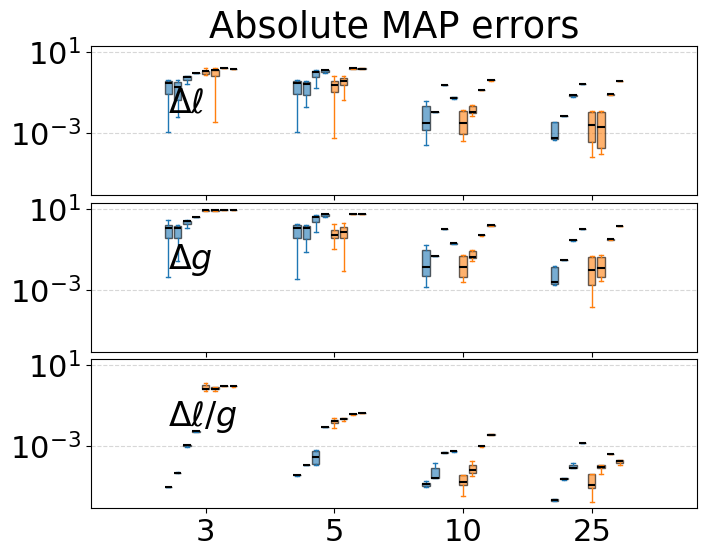

In [82]:
runs = 10

sigma_list = [0.0, 0.01, 0.1, 0.2]
n_list = [3, 5, 10, 25]
modes = ["GT", "PIGP"]
all_AE = np.zeros((len(n_list), len(sigma_list), len(modes), 3, runs))

Al = ["withAl", "fixedAl"] #fixedAl #hier PIGP
GTsigma = ["no_extraGTsigma", "extraGTsigma"]
GTpoints = ["extraGTpoints", "extraGTpoints"] #hier GT

Al_mode = "withAl"
sigma_mode = "extraGTsigma"
point_mode = "extraGTpoints"
for n_idx, npoints in enumerate(n_list):
    for sigma_idx, sigma in enumerate(sigma_list):
        for j, mode in enumerate(modes):
            for run in range(0, runs):
                if mode == "GT":
                    data_ex2 = np.load(os.path.join(data_dir_ex2, Al_mode, sigma_mode, point_mode,
                                                    f"Ex2_{mode}_n{npoints}_sigma{sigma:.2f}_{run}.npz"))
                    learned_parameters = data_ex2["learned_parameters"]
                    true_parameters = data_ex2["true_parameters"]
                else:
                    data_ex2 = np.load(os.path.join(data_dir_ex2, Al_mode, 
                                                    f"Ex2_{mode}_n{npoints}_sigma{sigma:.2f}_{run}.npz"))
                    learned_parameters = data_ex2["learned_parameters"]
                    true_parameters = data_ex2["true_parameters"]
                all_AE[n_idx, sigma_idx, j, 0, run] = abs(learned_parameters[0]-true_parameters[0]) 
                all_AE[n_idx, sigma_idx, j, 1, run] = abs(learned_parameters[1]-true_parameters[1])
                all_AE[n_idx, sigma_idx, j, 2, run] = abs(learned_parameters[0]/learned_parameters[1]-true_parameters[0]/true_parameters[1])

# --- plotting parameters ---
width = 0.06
group_spacing = 0.35
num_boxes_per_group = len(modes) * len(sigma_list)

colors = list(mcolors.TABLEAU_COLORS.values())

fig = plt.figure(figsize=(18, 6))
gs = gridspec.GridSpec(1, 2, width_ratios=[2, 2], wspace=0.3)

# --- LEFT AXIS: split into 3 rows ---
gs_left = gridspec.GridSpecFromSubplotSpec(3, 1, subplot_spec=gs[0, 0], hspace=0.05)

ax00 = fig.add_subplot(gs_left[0, 0])
ax01 = fig.add_subplot(gs_left[1, 0], sharey=ax00)
ax02 = fig.add_subplot(gs_left[2, 0], sharey=ax00)

axes = [ax00, ax01, ax02]

# --- plotting ---
for param_idx, ax in enumerate(axes):

    for n_idx, n in enumerate(n_list):

        group_pos = n_idx * (num_boxes_per_group * width + group_spacing)

        for mode_idx, mode in enumerate(modes):

            for sigma_idx, sigma in enumerate(sigma_list):

                pos = group_pos + (mode_idx * len(sigma_list) + sigma_idx) * width

                data = all_AE[n_idx, sigma_idx, mode_idx, param_idx]

                ax.boxplot(
                    data,
                    positions=[pos],
                    widths=width * 0.8,
                    patch_artist=True,
                    showfliers=False,
                    boxprops=dict(
                        facecolor=colors[mode_idx],
                        alpha=0.6
                    ),
                    medianprops=dict(color="black", linewidth=1.5),
                    whiskerprops=dict(color=colors[mode_idx]),
                    capprops=dict(color=colors[mode_idx])
                )

# --- axis labels ---
ax00.text(0, 1e-2, r"$\Delta \ell$", fontsize=24)
ax01.text(0, 1e-2, r"$\Delta g$", fontsize=24)
ax02.text(0, 1e-2, r"$\Delta \ell/g$", fontsize=24)

ax00.set_title("Absolute MAP errors")

# --- formatting ---
for ax in axes:

    AE_xtick_positions = [
        i * (num_boxes_per_group * width + group_spacing)
        + width * num_boxes_per_group / 2
        for i in range(len(n_list))
    ]

    AE_xtick_labels = [f"{n}" for n in n_list]

    ax.set_xticks(AE_xtick_positions, AE_xtick_labels)
    ax.set_yscale("log")
    ax.grid(True, axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()

# plt.savefig(os.path.join(save_dir, "Ex2_metrics.png"), dpi=300, bbox_inches='tight')
plt.show()

<>:99: SyntaxWarning: invalid escape sequence '\e'
<>:99: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_3562/2120103453.py:99: SyntaxWarning: invalid escape sequence '\e'
  ax_laplace.set_ylabel(r"$\ell_2$", fontsize=22)"""


tensor([[4.5802e-07, 1.7652e-06],
        [1.7652e-06, 6.9313e-06]])


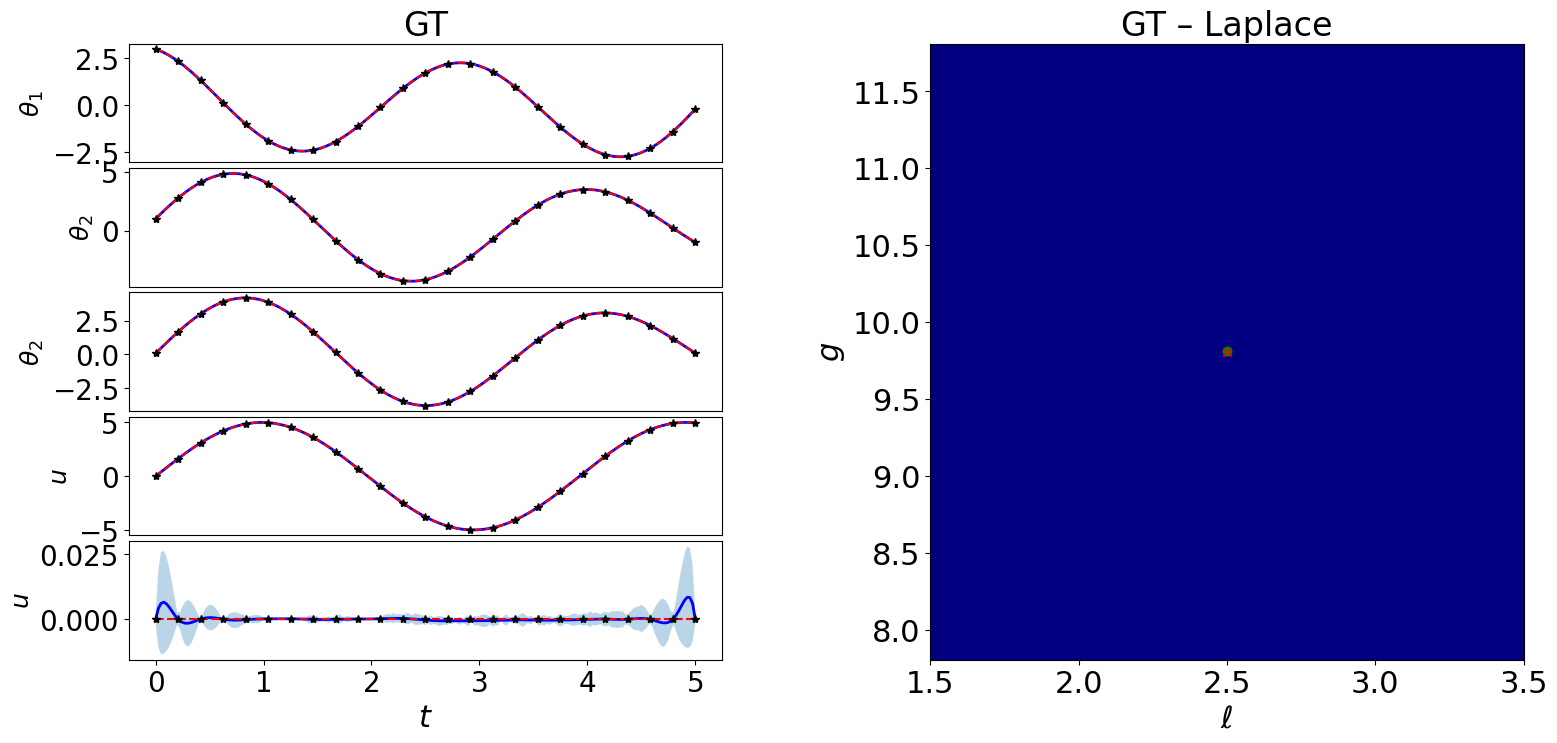

In [192]:
#npoints = 10
sigma = 0.001
npoint_list = [3, 5, 10, 25] 
modes = ["GT"]
titles = ["GT"]
num_tasks_list = [5, 6]  # given
run = 0
Al_mode = "withAl"
sigma_mode = "extraGTsigma"
point_mode = "extraGTpoints"

for npoints in [25]:
    cmap = "jet"
    fig = plt.figure(figsize=(18, 8), constrained_layout=True)
    #plt.suptitle(npoints)
    task_labels = [r"$\theta_1$", r"$\theta_2$", r"$\theta_2$", r"$u$", r"$u$", r"$u$"]  
    color_axes = []
    # Outer GridSpec: 3 rows × 1 column, height proportional to num_tasks
    outer = gridspec.GridSpec(1, 1,  hspace=0.35)
    
    for row, (mode, title,  num_tasks) in enumerate(zip(modes, titles, num_tasks_list)):
    
        # ----------------- Load dataset -----------------
        if mode == "GT":
            data_ex1 = np.load(os.path.join(data_dir_ex1, Al_mode, sigma_mode, point_mode,
                                            f"Ex1_{mode}_n{npoints}_sigma{sigma:.2f}_{run}.npz"))
        else:
            data_ex1 = np.load(os.path.join(data_dir_ex1, Al_mode, 
                                            f"Ex1_{mode}_n{npoints}_sigma{sigma:.2f}_{run}.npz"))
        for key in data_ex1:
                globals()[key] = torch.tensor(data_ex1[key])
        
    
        # ----------------- Create nested GridSpec per row -----------------
        row_gs = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=outer[row], width_ratios=[4, 4], wspace=0.35)
            
    
    
        # ----------------- LEFT BLOCK: stacked time series -----------------
        inner = gridspec.GridSpecFromSubplotSpec(num_tasks, 1, subplot_spec=row_gs[0], hspace=0.05)
        for i in range(num_tasks):
            ax = fig.add_subplot(inner[i, 0])
            ax.plot(test_x, mean[:, i], 'b', linewidth=2)
            ax.fill_between(test_x, lower[:, i], upper[:, i], alpha=0.3)
            ax.plot(test_x, test_y[:, i], "r--")
            mask = ~torch.isnan(train_y[:, i])
            ax.plot(train_x[mask], train_y[mask, i], 'k*')
            ax.set_ylabel(task_labels[i] if i < len(task_labels) else f"f_{i+1}", fontsize=22)
            if i < num_tasks - 1:
                ax.tick_params(labelbottom=False, bottom = False, labelsize=20)
            else:
                ax.set_xlabel(r"$t$", fontsize=22)
                ax.tick_params(labelsize=20)
            if i == 0:
                ax.set_title(title, fontsize=24)
           # ax.tick_params(labelsize=16)  # smaller font for stacked plots
            ax.set_ylabel(task_labels[i], fontsize=18)
            """if i==1:
                y_ticks = [8, 0, -8]
            if i>=2:
                y_ticks = [10, 0, -10]
            if i == 0: 
                y_ticks = [4, 0, -4]
            ax.set_yticks(y_ticks)
            ax.set_yticklabels([f"{t:.0f}" for t in y_ticks], fontsize=16)"""
        # ----------------- MIDDLE BLOCK: Laplace / Bayes posterior -----------------
        ax_laplace = fig.add_subplot(row_gs[1])
        N = 1000
        ax_laplace.plot(true_parameters[0], true_parameters[1], "go")
        ax_laplace.plot(learned_parameters[0], learned_parameters[1], "rx")
        xlim = (learned_parameters[0]-1, learned_parameters[0]+1)
        ylim = (learned_parameters[1]-2, learned_parameters[1]+2)
        mesh_1 = torch.linspace(xlim[0], xlim[1], N)
        mesh_2 = torch.linspace(ylim[0], ylim[1], N)
        param1, param2 = torch.meshgrid(mesh_1, mesh_2, indexing="xy")
        mu = learned_parameters[:2]
        try:
                print(laplace_covariance[:2, :2])
                inv_cov = torch.inverse(laplace_covariance[:2, :2])
                param_vec = torch.stack([param1.flatten(), param2.flatten()], dim=-1)
                exponent_raw = torch.einsum('bi,ij,bj->b', param_vec - mu, inv_cov, param_vec - mu)
                prob_density = torch.exp(-0.5 * (exponent_raw - exponent_raw.min()))
                prob_density /= prob_density.sum() * (mesh_1[1]-mesh_1[0])*(mesh_2[1]-mesh_2[0])
                prob_density = prob_density.reshape(N, N)
        
                surf = ax_laplace.pcolormesh(param1, param2, prob_density, cmap=cmap, shading="auto")
                ax_laplace.plot(true_parameters[0], true_parameters[1], "go")
                ax_laplace.plot(learned_parameters[0], learned_parameters[1], "rx")
                ax_laplace.set_title(f"{title} – Laplace", fontsize=24)
        except:
               print(npoints, sigma, "there was a problem with the covariance")
       
    
        ax_laplace.set_xlabel(r"$\ell$", fontsize=22)
        ax_laplace.set_ylabel(r"$g$", fontsize=22)
        """x_ticks = [0.85, 1.0, 1.15]
        ax_laplace.set_xticks(x_ticks)
        ax_laplace.set_xticklabels([f"{t:.2f}" for t in x_ticks], fontsize=22)
        ax_laplace.set_ylabel(r"$\ell_2$", fontsize=22)"""
    
        
    
    
#plt.savefig(os.path.join(save_dir, "Ex1_PoC.png"), dpi=300,bbox_inches='tight')

tensor([ 2.5001,  9.8139, 21.3228,  0.9908])
tensor([[8.0055e-06]])


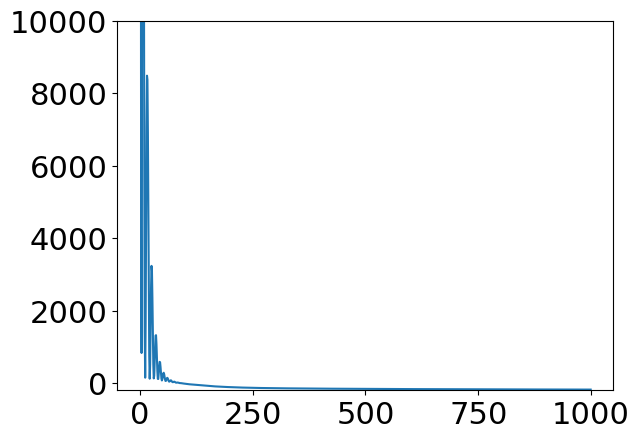

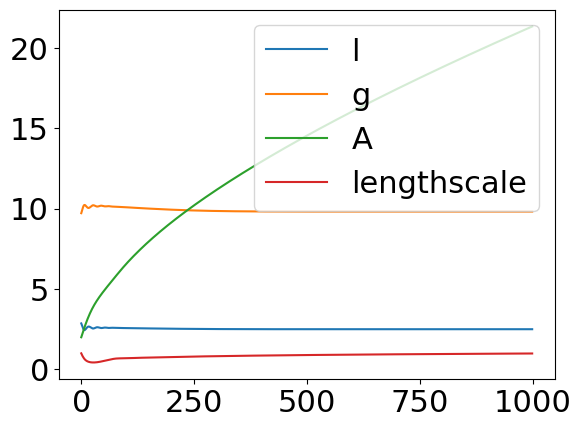

In [191]:
#mode = "GT"
#data_ex1 = np.load(os.path.join(data_dir_ex1, Al_mode, sigma_mode, point_mode,
                                       # f"Ex1_{mode}_n{npoints}_sigma{sigma:.2f}_{run}.npz"))
for key in data_ex1:
    #print(key)
    globals()[key] = torch.tensor(data_ex1[key])
plt.plot(range(len(loss)), loss)
plt.ylim(-200, 1e4)
plt.figure()
name = ["l", "g", "A", "lengthscale"]
for i in range(4):
    plt.plot(range(len(loss)), parameters_during_training[i], label = name[i])
    plt.legend()
    
print(learned_parameters)
print(torch.inverse(hessian[1:2, 1:2]))

In [20]:
np.sqrt(9.8/2.5)

np.float64(1.9798989873223332)